# Advanced — AI 기반 지반함몰 위험도 예측 실습

각 단계의 Task와 시작 구조가 제공됩니다. 핵심 분석 코드는 직접 작성하되, 요구사항과 사용할 함수는 명확히 안내합니다.

공통 조건: `random_state=42`, 테스트 데이터 25%, 위험등급 비율 유지

In [37]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [38]:
candidates = [
    Path("../data/hannam_sinkhole_data.xlsx"),
    Path("data/hannam_sinkhole_data.xlsx"),
    Path("hannam_sinkhole_data.xlsx"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
DATA_URL = (
    "https://raw.githubusercontent.com/GeoSeonghoHong/"
    "Seongho-Hong/main/data/hannam_sinkhole_data.xlsx"
)

if DATA_PATH is not None:
    print("로컬 데이터 사용:", DATA_PATH)
    df = pd.read_excel(DATA_PATH, sheet_name="training_data")
else:
    print("로컬 파일이 없어 GitHub에서 데이터를 불러옵니다.")
    df = pd.read_excel(DATA_URL, sheet_name="training_data")

print("shape:", df.shape)
df.head()

로컬 파일이 없어 GitHub에서 데이터를 불러옵니다.
shape: (733, 27)


,id,water_Y_5,water_Y_10,water_Y_15,water_Y_20,water_Y_25,water_Y_30,water_Y_35,water_Y_40,water_Y_45,...,sewer_Density,cavity_count,total_water_length,total_sewer_length,pipe_total_density,water_sewer_ratio,old_pipe_ratio,recent_pipe_ratio,cavity_density_interaction,risk
0,17752,94,30,57,45,124,65,119,0,0,...,83.2,8,540,465,83.2540,0.000649,0.533333,0.374129,666.032,2
1,16900,94,0,0,0,0,216,0,0,0,...,81.4,0,310,814,81.4310,0.000381,0.716192,0.283808,0.000,0
2,17323,31,34,0,47,3,211,0,0,0,...,76.2,0,326,751,76.2326,0.000428,0.598886,0.369545,0.000,1
3,17964,0,0,0,0,349,0,0,0,0,...,75.3,0,349,753,75.3349,0.000463,0.924682,0.075318,0.000,1
4,17119,0,68,0,60,0,257,102,0,0,...,75.0,0,487,407,75.0487,0.000649,0.468680,0.455257,0.000,1


## Task 1. 데이터 구조와 위험등급 분포 확인

1. 데이터 크기와 자료형을 확인하세요.
2. 결측치와 중복 행을 확인하세요.
3. 위험등급 분포를 표와 막대그래프로 표현하세요.

힌트: `info`, `isna`, `duplicated`, `value_counts`, `plot`

In [39]:
# Task 1의 코드를 아래에 작성하세요.
# 결과에는 데이터 품질 요약과 위험등급 분포 그래프가 포함되어야 합니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          733 non-null    int64  
 1   water_Y_5                   733 non-null    int64  
 2   water_Y_10                  733 non-null    int64  
 3   water_Y_15                  733 non-null    int64  
 4   water_Y_20                  733 non-null    int64  
 5   water_Y_25                  733 non-null    int64  
 6   water_Y_30                  733 non-null    int64  
 7   water_Y_35                  733 non-null    int64  
 8   water_Y_40                  733 non-null    int64  
 9   water_Y_45                  733 non-null    int64  
 10  water_Y_50                  733 non-null    int64  
 11  water_Y_55                  733 non-null    int64  
 12  water_Density               733 non-null    float64
 13  sewer_Y_5                   733 non

In [5]:
df.isna().sum()

,0
id,0
water_Y_5,0
water_Y_10,0
water_Y_15,0
water_Y_20,0
water_Y_25,0
water_Y_30,0
water_Y_35,0
water_Y_40,0
water_Y_45,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['risk'].value_counts()

,count
risk,
0,293
1,256
2,184


<Axes: xlabel='risk'>

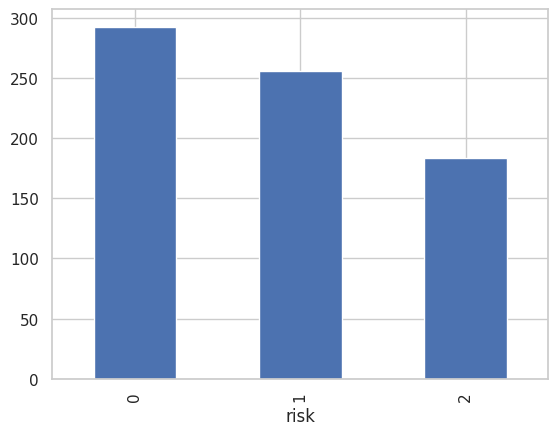

In [7]:
df['risk'].value_counts().plot(kind='bar')

## Task 2. Model A/B/C 입력 변수 구성

1. Model A: 상·하수도관 밀집도 2개
2. Model B: 시공 시기별 관로 길이, 밀집도, 공동 개수
3. Model C: Model B + 파생 변수

힌트: 아래에 제공된 시공 시기별 변수와 파생 변수 목록을 조합하세요. `id`와 `risk`는 입력 변수에서 제외합니다.

In [11]:
df.columns

Index(['id', 'water_Y_5', 'water_Y_10', 'water_Y_15', 'water_Y_20',
       'water_Y_25', 'water_Y_30', 'water_Y_35', 'water_Y_40', 'water_Y_45',
       'water_Y_50', 'water_Y_55', 'water_Density', 'sewer_Y_5', 'sewer_Y_10',
       'sewer_Y_15', 'sewer_Y_20', 'sewer_Density', 'cavity_count',
       'total_water_length', 'total_sewer_length', 'pipe_total_density',
       'water_sewer_ratio', 'old_pipe_ratio', 'recent_pipe_ratio',
       'cavity_density_interaction', 'risk'],
      dtype='object')

In [87]:
water_features = [f"water_Y_{year}" for year in range(5, 60, 5)]
sewer_features = [f"sewer_Y_{year}" for year in range(5, 25, 5)]
derived_features = [
    "total_water_length", "total_sewer_length", "pipe_total_density",
    "water_sewer_ratio", "old_pipe_ratio", "recent_pipe_ratio",
    "cavity_density_interaction",
]

# Task 2: 세 변수 목록을 완성하세요.
basic_features = ['water_Density', 'sewer_Density']
raw_features = (
    water_features
    + ["water_Density"]
    + sewer_features
    + ["sewer_Density", "cavity_count"]
)
derived_features = [
    "total_water_length",
    "total_sewer_length",
    "pipe_total_density",
    "water_sewer_ratio",
    "old_pipe_ratio",
    "recent_pipe_ratio",
    "cavity_density_interaction",
]

engineered_features = raw_features + derived_features

## Task 3. 공통 학습·평가 함수 구현

1. 데이터를 75:25로 분리하세요.
2. 위험등급 비율을 유지하세요.
3. XGBoost 모델을 학습하고 평가 데이터를 예측하세요.
4. Accuracy와 Macro F1-score를 계산하세요.
5. 모델, 변수명, 정답, 예측값을 함께 반환하세요.

힌트: `train_test_split(..., stratify=y)`, `XGBClassifier`, `fit`, `predict`, `accuracy_score`, `f1_score(..., average="macro")`

In [122]:
def evaluate_model(name, features):
    X = df[features].copy()
    y = df["risk"].copy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state= 42, stratify = y)

    model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.2,
        random_state=32,
    )
    model.fit(X_train, y_train)

    pre = model.predict(X_test)
    accuracy = accuracy_score(y_test, pre)
    f1 = f1_score(y_test, pre, average= 'macro')

    return {
        "model": name,
        "accuracy": accuracy,
        "f1": f1,
        "model_object": model,
        "features": features,
        "y_test": y_test,
        "pre": pre,
    }

## Task 4. 세 모델 학습과 성능 비교

Model A/B/C를 같은 조건으로 학습하고 Accuracy와 Macro F1-score를 표와 그래프로 비교하세요.

힌트: 결과 객체를 `results` 리스트에 모으면 반복문으로 비교표를 만들 수 있습니다.

In [123]:
# Task 4: 세 모델을 학습하세요.
result_a = evaluate_model("Model A", basic_features)
result_b = evaluate_model("Model B", raw_features)
result_c = evaluate_model("Model C", engineered_features)
results = [result_a, result_b, result_c]

# Task 4: results를 이용해 비교표와 그래프를 작성하세요.

In [124]:
results

[{'model': 'Model A',
  'accuracy': 0.46195652173913043,
  'f1': 0.4539378665373434,
  'model_object': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=0.2, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=500,
                n_jobs=None, num_parallel_tree=None, ...),
  'features': ['water_Density', 'sewer_Density'],
  'y_test': 260    1
  164    1
  590    1
  192    2
  162    1
      

In [125]:
result_df = pd.DataFrame(data = results, columns = ["model", "accuracy", "f1"])
result_df


,model,accuracy,f1
0,Model A,0.461957,0.453938
1,Model B,0.793478,0.795592
2,Model C,0.815217,0.818158


<Axes: xlabel='model'>

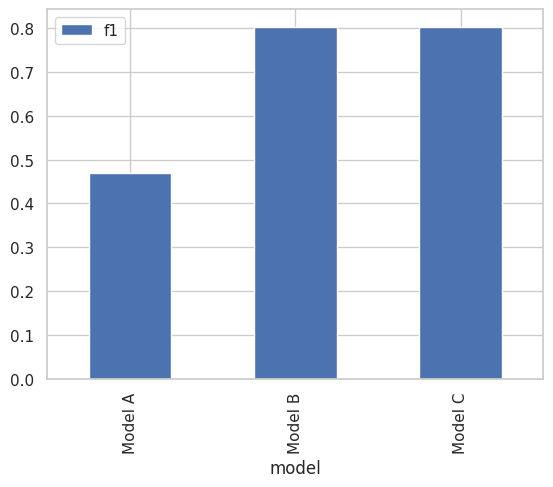

In [113]:
result_df.plot(x = "model", y = "f1", kind = "bar")

In [126]:
df.columns

Index(['id', 'water_Y_5', 'water_Y_10', 'water_Y_15', 'water_Y_20',
       'water_Y_25', 'water_Y_30', 'water_Y_35', 'water_Y_40', 'water_Y_45',
       'water_Y_50', 'water_Y_55', 'water_Density', 'sewer_Y_5', 'sewer_Y_10',
       'sewer_Y_15', 'sewer_Y_20', 'sewer_Density', 'cavity_count',
       'total_water_length', 'total_sewer_length', 'pipe_total_density',
       'water_sewer_ratio', 'old_pipe_ratio', 'recent_pipe_ratio',
       'cavity_density_interaction', 'risk'],
      dtype='object')

In [150]:
new_features =['water_Y_5', 'water_Y_10', 'water_Y_15', 'water_Y_20',
       'water_Y_25', 'water_Y_30', 'water_Y_35', 'water_Y_40', 'water_Y_45',
       'water_Y_50', 'water_Y_55', 'water_Density', 'sewer_Y_5', 'sewer_Y_10', 'sewer_Y_20', 'sewer_Density', 'cavity_count',
       'total_water_length', 'total_sewer_length', 'pipe_total_density',
       'water_sewer_ratio', 'old_pipe_ratio',
       'cavity_density_interaction']

In [151]:
X = df[new_features].copy()
y = df["risk"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state= 42, stratify = y)
model =     model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.2,
        random_state=32,
    )
model.fit(X_train, y_train)

pre = model.predict(X_test)
accuracy = accuracy_score(y_test, pre)
f1 = f1_score(y_test, pre, average= 'macro')

In [152]:
pre = model.predict(X_test)
accuracy = accuracy_score(y_test, pre)
f1 = f1_score(y_test, pre, average= 'macro')
print(accuracy, f1)

0.7989130434782609 0.803045742434905


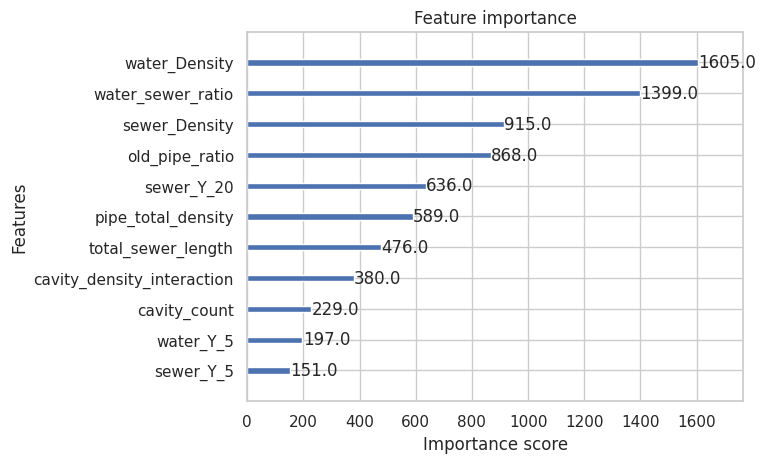

In [153]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# model은 학습된 XGBoost 객체
plot_importance(model)
plt.show()

## Task 5. 최고 모델의 오분류 분석

1. Macro F1-score가 가장 높은 모델을 선택하세요.
2. Confusion Matrix와 classification report를 출력하세요.
3. 실제 High 등급을 놓친 사례 수를 확인하세요.

힌트: `max`, `confusion_matrix`, `classification_report`, `sns.heatmap`

In [ ]:
# Task 5의 코드를 작성하세요.
best_result = None


## Task 6. 변수 중요도와 공학적 해석

1. Model C의 변수 중요도 상위 15개를 표와 그래프로 표현하세요.
2. 가장 중요한 변수와 모델별 성능 차이를 설명하세요.
3. 변수 중요도가 인과관계를 의미하지 않는 이유를 서술하세요.

힌트: `result_c["model_object"].feature_importances_`, `result_c["features"]`, `sort_values`

In [ ]:
# Task 6의 변수 중요도 표와 그래프를 작성하세요.
importance = None
